# Spedition MLP — 5-Stations Diesel-Preisoptimierung

**CRISP-DM** | Studienprojekt HS Aalen – Predictive Analytics Sem 1

Ziel: 72-Stunden-Vorschau auf Dieselpreise an 5 festen Stationen entlang der LKW-Routen.
Der Disponent sieht, welche Station in den nächsten 72 h am günstigsten ist.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path
from math import radians, sin, cos, sqrt, atan2, degrees

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import folium
from IPython.display import display
from dotenv import load_dotenv

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
import joblib

load_dotenv("../.env")
%matplotlib inline
sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


---
## § 1 — Business Understanding

### Szenario: Spedition mit 5 LKWs auf 5 Festrouten

| Parameter | Wert |
|---|---|
| LKWs | 5 |
| Tankfüllung | 400 L |
| Stationen | 5 (eine pro Route, ~100 km von Aalen) |
| Forecast-Horizont | 72 h |

**Ökonomische Motivation:**  
Bei 1 ct/L Preisunterschied und 400 L Tankfüllung = **€ 4 pro Befüllung**.  
Bei 5 LKWs täglich = bis zu **€ 20/Tag** Ersparnis durch optimale Stationsauswahl.

**Erfolgskennzahl:** Cheapest-Station Pick Accuracy — Anteil der Stunden, in denen die
vorhergesagte günstigste Station tatsächlich die günstigste ist (Random Baseline: 20 %).

In [3]:
# Spedition scenario constants
N_TRUCKS       = 5
TANK_LITER     = 400
ROUTES         = ["N", "NE", "E", "SW", "NW"]
FUEL_PRICE_AVG = 1.65
FILLS_PER_DAY  = 1
TARGET_HORIZON = 72

print(f"Szenarien-Check:")
print(f"  Bei 1 ct/L Unterschied × {TANK_LITER} L = {TANK_LITER * 0.01:.2f} € / Befüllung")
print(f"  Bei {N_TRUCKS} LKWs täglich = {N_TRUCKS * TANK_LITER * 0.01:.2f} €/Tag Einsparpotenzial")

Szenarien-Check:
  Bei 1 ct/L Unterschied × 400 L = 4.00 € / Befüllung
  Bei 5 LKWs täglich = 20.00 €/Tag Einsparpotenzial


---
## § 2 — Data Understanding: Stationsdiscovery

Wir suchen pro Himmelsrichtungssektor (N, NE, E, SW, NW) die Tankstelle mit der
besten Datenverfügbarkeit im Ring 80–120 km um Aalen.

In [4]:
# Cell 2a — Stationen laden, Haversine-Distanz und Bearing berechnen
# Ergebnis wird gecacht → stations_geo.parquet (nur beim ersten Aufruf langsam)
from scripts.data_transform import load_config

REFRESH_STATIONS = False  # True: CSV neu einlesen und Cache überschreiben

cfg = load_config()
stations_cache = cfg["processed_dir"] / "stations_geo.parquet"

AALEN = (48.8374, 10.0936)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

def bearing_deg(lat1, lon1, lat2, lon2):
    dlon = radians(lon2 - lon1)
    x = sin(dlon) * cos(radians(lat2))
    y = (cos(radians(lat1)) * sin(radians(lat2))
         - sin(radians(lat1)) * cos(radians(lat2)) * cos(dlon))
    return (degrees(atan2(x, y)) + 360) % 360

if stations_cache.exists() and not REFRESH_STATIONS:
    stations = pd.read_parquet(stations_cache)
    print(f"Cache geladen: {stations_cache}  ({len(stations):,} Stationen)")
else:
    stations_path = cfg["data_path"] / "stations" / "stations.csv"
    print(f"Lese CSV (einmalig langsam): {stations_path}")
    stations = pd.read_csv(
        stations_path,
        usecols=["uuid", "name", "brand", "post_code", "city", "latitude", "longitude"],
        dtype={"uuid": str, "post_code": str},
    )
    stations = stations.dropna(subset=["latitude", "longitude"])
    stations["dist_km"] = stations.apply(
        lambda r: haversine_km(AALEN[0], AALEN[1], r.latitude, r.longitude), axis=1
    )
    stations["bearing"] = stations.apply(
        lambda r: bearing_deg(AALEN[0], AALEN[1], r.latitude, r.longitude), axis=1
    )
    stations.to_parquet(stations_cache, index=False)
    print(f"Cache gespeichert: {stations_cache}  ({len(stations):,} Stationen)")

# Ring 80–120 km
candidates = stations[(stations.dist_km >= 80) & (stations.dist_km <= 120)].copy()
print(f"{len(candidates)} Kandidaten im 80–120 km Ring")

Cache geladen: /home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/data/processed/stations_geo.parquet  (15,442 Stationen)
1252 Kandidaten im 80–120 km Ring


In [5]:
# Cell 2b — Himmelsrichtungssektor zuweisen + beste Station je Sektor
# Preisereignisse werden gecacht → candidates_events.parquet (CSV-Scan nur einmalig)
from scripts.data_transform import load_raw_prices

REFRESH_CANDIDATES = False  # True: Preisereignisse neu scannen und Cache überschreiben

candidates_cache = cfg["processed_dir"] / "candidates_events.parquet"

def sector(b):
    if b < 22.5 or b >= 337.5: return "N"
    if b < 67.5:                return "NE"
    if b < 157.5:               return "E"
    if b < 247.5:               return "SW"
    return "NW"

if candidates_cache.exists() and not REFRESH_CANDIDATES:
    candidates = pd.read_parquet(candidates_cache)
    print(f"Cache geladen: {candidates_cache}  ({len(candidates):,} Kandidaten)")
else:
    candidates = candidates.copy()
    candidates["sector"] = candidates["bearing"].apply(sector)

    print("Lade Preisereignisse für Kandidaten-Stationen (ab 2020) …")
    raw_cand = load_raw_prices(
        cfg["data_path"],
        set(candidates.uuid),
        "diesel",
        start_date="2020-01-01",
        end_date=None,
    )
    event_counts = raw_cand.groupby("station_uuid").size().rename("n_events")
    candidates = candidates.join(event_counts, on="uuid").fillna({"n_events": 0})
    candidates["n_events"] = candidates["n_events"].astype(int)

    candidates.to_parquet(candidates_cache, index=False)
    print(f"Cache gespeichert: {candidates_cache}  ({len(candidates):,} Kandidaten)")

# Pro Sektor: Station mit den meisten Ereignissen
best = (
    candidates
    .sort_values("n_events", ascending=False)
    .groupby("sector")
    .first()
    .reset_index()[["sector", "uuid", "name", "brand", "city", "dist_km", "bearing", "n_events"]]
)
display(best)

Cache geladen: /home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/data/processed/candidates_events.parquet  (1,252 Kandidaten)


,sector,uuid,name,brand,city,dist_km,bearing,n_events
0,E,19275bf1-8186-47d8-b5eb-261431afaced,Esso Tankstelle,ESSO,OLCHING,113.858949,128.168493,79755
1,N,af8b14d6-0af5-4d86-a2d5-947dc569fd9a,AVIA Station,AVIA,Ipsheim,80.718475,19.790553,106953
2,NE,db307731-f6c4-4c45-9af4-1058e9b23397,AVIA Tankstelle,AVIA,Nürnberg,90.328753,48.378552,95701
3,NW,7bbb852b-e04e-48db-a1ee-8835cdbb9757,AVIA Tankstelle,AVIA,Mühlhausen,109.048750,295.275624,98375
4,SW,62c42eb1-3776-4c5c-aec5-22148a267465,RAN Station,RAN,Biberach,85.778462,194.950178,87324


In [6]:
# Cell 2c — Folium-Karte: alle Kandidaten (farbig je Sektor) + gewählte Stationen (Marker)
COLORS = {"N": "red", "NE": "orange", "E": "green", "SW": "blue", "NW": "purple"}

m = folium.Map(location=AALEN, zoom_start=8)
folium.Marker(
    AALEN,
    tooltip="Aalen (Ausgangspunkt)",
    icon=folium.Icon(color="black", icon="home")
).add_to(m)

for _, row in candidates.iterrows():
    color = COLORS.get(row.sector, "gray")
    folium.CircleMarker(
        [row.latitude, row.longitude],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.6,
        tooltip=f"{row.get('brand', '')} {row['name']} — {row.sector} {row.dist_km:.0f} km ({row.n_events} Ereignisse)",
    ).add_to(m)

best_uuids = set(best.uuid)
for _, row in best.iterrows():
    lat = candidates.loc[candidates.uuid == row.uuid, "latitude"].iloc[0]
    lng = candidates.loc[candidates.uuid == row.uuid, "longitude"].iloc[0]
    folium.Marker(
        [lat, lng],
        icon=folium.Icon(color=COLORS[row.sector], icon="star"),
        tooltip=f"AUSGEWÄHLT [{row.sector}]: {row['brand']} {row['name']} ({row.dist_km:.0f} km, {row.n_events} Ereignisse)",
    ).add_to(m)

m

In [7]:
# Cell 2d — UUID-Dict für data_transform_spedition.py ausgeben
print("# ── Paste into scripts/data_transform_spedition.py → SPEDITION_STATIONS ──")
print("SPEDITION_STATIONS: dict[str, str] = {")
for _, row in best.sort_values("sector").iterrows():
    print(f'    "Route_{row.sector}": "{row.uuid}",  # {row.get("brand", "?")} {row["name"]} — {row["city"]} ({row.dist_km:.0f} km)')
print("}")

# ── Paste into scripts/data_transform_spedition.py → SPEDITION_STATIONS ──
SPEDITION_STATIONS: dict[str, str] = {
    "Route_E": "19275bf1-8186-47d8-b5eb-261431afaced",  # ESSO Esso Tankstelle — OLCHING (114 km)
    "Route_N": "af8b14d6-0af5-4d86-a2d5-947dc569fd9a",  # AVIA AVIA Station — Ipsheim (81 km)
    "Route_NE": "db307731-f6c4-4c45-9af4-1058e9b23397",  # AVIA AVIA Tankstelle — Nürnberg (90 km)
    "Route_NW": "7bbb852b-e04e-48db-a1ee-8835cdbb9757",  # AVIA AVIA Tankstelle — Mühlhausen (109 km)
    "Route_SW": "62c42eb1-3776-4c5c-aec5-22148a267465",  # RAN RAN Station — Biberach (86 km)
}


---
> ### ⚠️ Schritt erforderlich: UUIDs in Script eintragen
>
> Kopiere die Ausgabe von Cell 2d nach
> `scripts/data_transform_spedition.py` → `SPEDITION_STATIONS` (Zeilen 48–54)
> und **speichere die Datei**, bevor du Cell 2e und alle folgenden Zellen ausführst.
>
> Danach zur Verifikation:
> ```
> python scripts/data_transform_spedition.py --debug
> ```
---

Aktuelle SPEDITION_STATIONS:
  Route_E: 19275bf1-8186-47d8-b5eb-261431afaced
  Route_N: af8b14d6-0af5-4d86-a2d5-947dc569fd9a
  Route_NE: db307731-f6c4-4c45-9af4-1058e9b23397
  Route_NW: 7bbb852b-e04e-48db-a1ee-8835cdbb9757
  Route_SW: 62c42eb1-3776-4c5c-aec5-22148a267465

Hourly shape: (104748, 5)  (2014-06-08 09:00:00 → 2026-05-20 20:00:00)
NaN-Anteil je Spalte:


diesel_Route_E     0.0
diesel_Route_N     0.0
diesel_Route_NE    0.0
diesel_Route_NW    0.0
diesel_Route_SW    0.0
Name: NaN %, dtype: float64

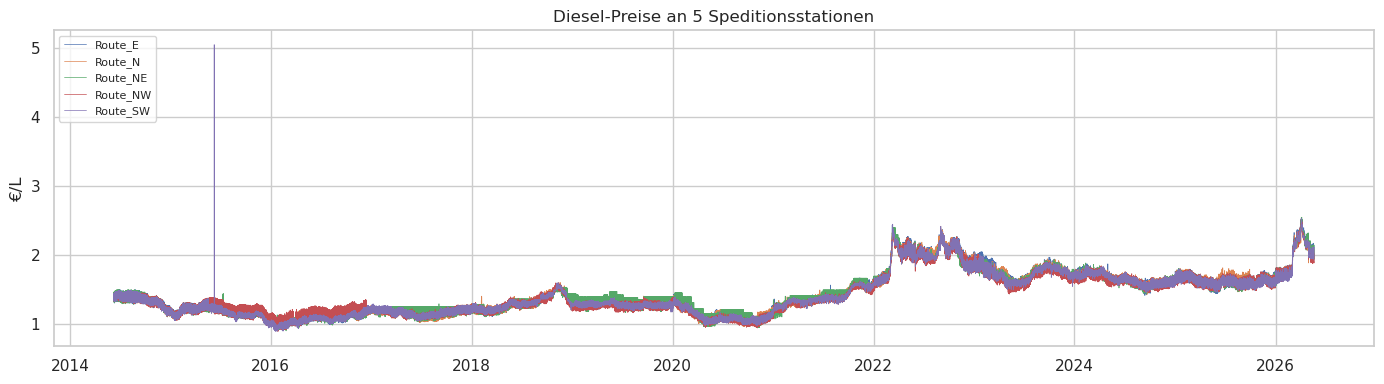

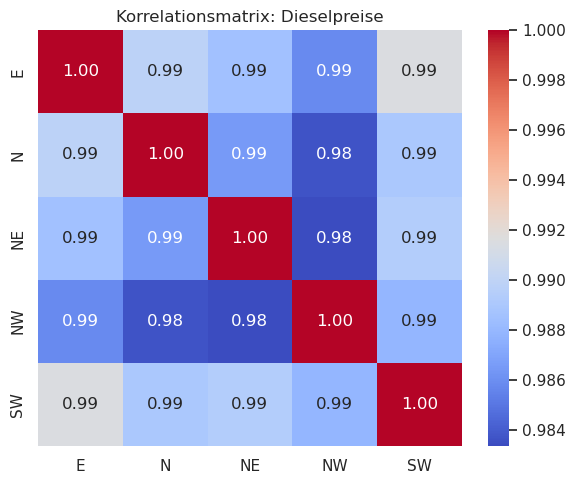

In [8]:
# Cell 2e — Preis-Zeitreihen + Korrelationsmatrix der 5 Stationen
# Importiert SPEDITION_STATIONS nach dem UUID-Update
import importlib
import scripts.data_transform_spedition as _spedmod
importlib.reload(_spedmod)
from scripts.data_transform_spedition import SPEDITION_STATIONS, aggregate_hourly_per_station

print("Aktuelle SPEDITION_STATIONS:")
for k, v in SPEDITION_STATIONS.items():
    print(f"  {k}: {v}")

if any(v == "TO_BE_SET" for v in SPEDITION_STATIONS.values()):
    raise ValueError("UUIDs noch nicht eingetragen — Cell 2d ausführen und Script updaten!")

raw5 = load_raw_prices(cfg["data_path"], set(SPEDITION_STATIONS.values()), "diesel")
hourly5 = aggregate_hourly_per_station(raw5, SPEDITION_STATIONS, "diesel")
print(f"\nHourly shape: {hourly5.shape}  ({hourly5.index.min()} → {hourly5.index.max()})")
print(f"NaN-Anteil je Spalte:")
display((hourly5.isna().mean() * 100).round(2).rename("NaN %"))

# Zeitreihen
fig, ax = plt.subplots(figsize=(14, 4))
for col in hourly5.columns:
    ax.plot(hourly5.index, hourly5[col], lw=0.5, label=col.replace("diesel_", ""))
ax.set_title("Diesel-Preise an 5 Speditionsstationen")
ax.set_ylabel("€/L")
ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

# Korrelationsmatrix
fig, ax = plt.subplots(figsize=(6, 5))
corr_labels = [c.replace("diesel_Route_", "") for c in hourly5.columns]
sns.heatmap(
    hourly5.corr(), annot=True, fmt=".2f", cmap="coolwarm",
    xticklabels=corr_labels, yticklabels=corr_labels, ax=ax
)
ax.set_title("Korrelationsmatrix: Dieselpreise")
plt.tight_layout()
plt.show()

---
## § 3 — Data Preparation

- `SpeditionDataLoader` erstellt Feature-Matrix X und Zielmatrix y (5 Stationen × 72 Horizonte)
- StandardScaler: fit auf Trainingsdaten, transform auf Val/Test
- Split: Train 2014–2021 | Val 2022–2023 | Test 2024–heute

In [9]:
from scripts.data_transform_spedition import SpeditionDataLoader

loader = SpeditionDataLoader(forecast_horizon=TARGET_HORIZON, fuel_type="diesel", debug=True)
X, y = loader.load()

print(f"\nFeature-Matrix X: {X.shape}")
print(f"Ziel-Matrix    y: {y.shape}")
print(f"NaN in X: {X.isna().sum().sum()} | NaN in y: {y.isna().sum().sum()}")

# Feature-Gruppen
lag_cols  = [c for c in X.columns if "_lag_"  in c]
roll_cols = [c for c in X.columns if "_roll_" in c]
temp_cols = ["hour", "day_of_week", "is_weekend", "is_holiday"]
other_cols = [c for c in X.columns if c not in lag_cols + roll_cols + temp_cols]
print(f"\nFeature-Gruppen:")
print(f"  Lag:      {len(lag_cols):3d}")
print(f"  Rolling:  {len(roll_cols):3d}")
print(f"  Other:    {len(other_cols):3d}  (price_t, diff, momentum, trend)")
print(f"  Temporal: {len(temp_cols):3d}")
print(f"  Total:    {len(X.columns):3d}")
print(f"  Targets:  {len(y.columns):3d}  (5 Stationen × {TARGET_HORIZON} Horizonte)")

[SpeditionDataLoader] Loading from cache: /home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/data/processed/spedition_5stations_diesel_all_all.parquet


/home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/scripts/data_transform_spedition.py:172: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[tc] = df[col].shift(-step)
/home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/scripts/data_transform_spedition.py:172: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[tc] = df[col].shift(-step)
/home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/scripts/data_transform_spedition.py:172: Performanc

[SpeditionDataLoader] Feature matrix ready: X=(104508, 99), y=(104508, 360)

Feature-Matrix X: (104508, 99)
Ziel-Matrix    y: (104508, 360)
NaN in X: 0 | NaN in y: 0

Feature-Gruppen:
  Lag:       45
  Rolling:   30
  Other:     20  (price_t, diff, momentum, trend)
  Temporal:   4
  Total:     99
  Targets:  360  (5 Stationen × 72 Horizonte)


In [10]:
X_train, X_val, X_test, y_train, y_val, y_test = loader.train_val_test_split(X, y)

# Nur vollständige Zeilen behalten
valid_train = X_train.dropna().index.intersection(y_train.dropna().index)
valid_val   = X_val.dropna().index.intersection(y_val.dropna().index)
valid_test  = X_test.dropna().index.intersection(y_test.dropna().index)

X_train = X_train.loc[valid_train]; y_train = y_train.loc[valid_train]
X_val   = X_val.loc[valid_val];     y_val   = y_val.loc[valid_val]
X_test  = X_test.loc[valid_test];   y_test  = y_test.loc[valid_test]

print(f"Nach NaN-Drop: Train={len(X_train):,} | Val={len(X_val):,} | Test={len(X_test):,}")

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

print("Scaling abgeschlossen (fit auf Train, transform auf Val/Test)")

  Train : 2014-06-15 09:00:00  →  2021-12-31 23:00:00  (66,159 rows)
  Val   : 2022-01-01 00:00:00  →  2023-12-31 23:00:00  (17,520 rows)
  Test  : 2024-01-01 00:00:00  →  2026-05-17 20:00:00  (20,829 rows)
Nach NaN-Drop: Train=66,159 | Val=17,520 | Test=20,829
Scaling abgeschlossen (fit auf Train, transform auf Val/Test)


---
## § 4 — Modeling

- **Baseline**: Persistence (letzter bekannter Preis für alle 72 Horizonte)
- **TimeSeriesSplit CV** (5 Folds auf Trainingsdaten) zur Architekturvalidierung
- **MLPRegressor** `(256, 128)` — Multi-Output: 5 Stationen × 72 Horizonte = 360 Ziele

In [11]:
# Cell 4a — Persistence-Baseline
# Für jede Zielstunde: letzter bekannter Preis = Vorhersage
# Implementiert als DummyRegressor (mean-Strategie als obere Schranke)

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_s, y_train_s)

y_dummy_s = dummy.predict(X_test_s)
y_dummy   = scaler_y.inverse_transform(y_dummy_s)
y_true    = y_test.values

baseline_mae  = mean_absolute_error(y_true, y_dummy)
baseline_rmse = np.sqrt(mean_squared_error(y_true, y_dummy))
print(f"Persistence Baseline  — MAE: {baseline_mae:.5f} | RMSE: {baseline_rmse:.5f}")

Persistence Baseline  — MAE: 0.45463 | RMSE: 0.48606


In [12]:
# Cell 4b — TimeSeriesSplit CV (Architektur-Check, 5 Folds)
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_s)):
    m = MLPRegressor(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        n_iter_no_change=15,
    )
    m.fit(X_train_s[tr_idx], y_train_s[tr_idx])
    pred_s = m.predict(X_train_s[va_idx])
    pred   = scaler_y.inverse_transform(pred_s)
    truth  = y_train.iloc[va_idx].values
    mae    = mean_absolute_error(truth, pred)
    cv_scores.append(mae)
    print(f"  Fold {fold + 1}  MAE: {mae:.5f}  (Iter: {m.n_iter_})")

print(f"\nMean CV MAE: {np.mean(cv_scores):.5f} ± {np.std(cv_scores):.5f}")

  Fold 1  MAE: 0.02863  (Iter: 127)
  Fold 2  MAE: 0.02154  (Iter: 124)
  Fold 3  MAE: 0.03477  (Iter: 191)
  Fold 4  MAE: 0.02466  (Iter: 140)
  Fold 5  MAE: 0.02188  (Iter: 109)

Mean CV MAE: 0.02630 ± 0.00494


In [13]:
# Cell 4c — Finales Modell auf vollem Trainingssatz
model = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    n_iter_no_change=20,
    verbose=False,
)
model.fit(X_train_s, y_train_s)
print(f"Training abgeschlossen — Iterationen: {model.n_iter_}")
print(f"Bester Val-Loss (skaliert): {model.best_validation_score_:.6f}")

# Validation-Set Score
y_val_pred   = scaler_y.inverse_transform(model.predict(X_val_s))
val_mae      = mean_absolute_error(y_val.values, y_val_pred)
print(f"Val MAE:  {val_mae:.5f}")

Training abgeschlossen — Iterationen: 121
Bester Val-Loss (skaliert): 0.972337
Val MAE:  0.04334


---
## § 5 — Evaluation

- MAE / RMSE pro Horizont (72 Punkte)
- Cheapest-Station Pick Accuracy (Kernkennzahl, Ziel > 20 %)
- Spearman-Rangkorrelation zwischen vorhergesagtem und echtem Preisranking
- Simulierter Kosten-Impact: Zufallsrouting vs. modellbasierte Auswahl

Test MAE:  0.03528  |  Test RMSE: 0.04834
Baseline MAE: 0.45463  →  Skill: 92.2 %


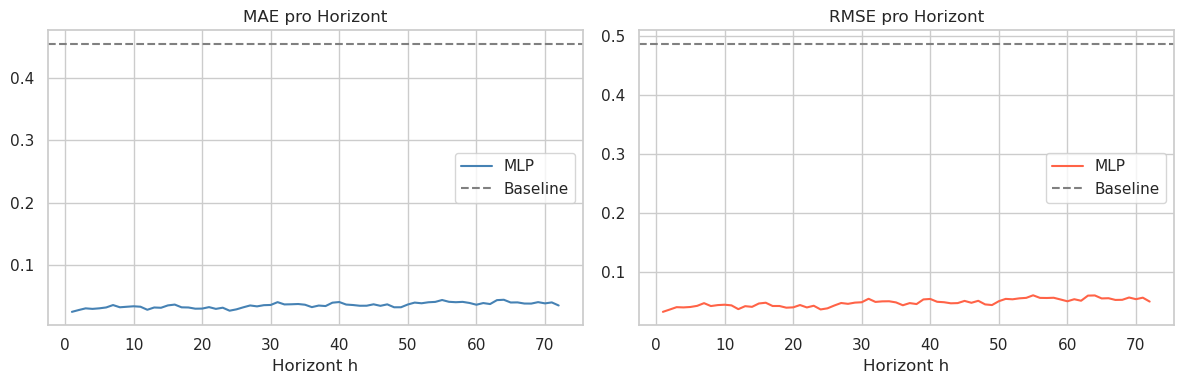

In [14]:
# Cell 5a — MAE / RMSE pro Horizont
y_pred_s = model.predict(X_test_s)
y_pred   = scaler_y.inverse_transform(y_pred_s)
y_true   = y_test.values

test_mae  = mean_absolute_error(y_true, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"Test MAE:  {test_mae:.5f}  |  Test RMSE: {test_rmse:.5f}")
print(f"Baseline MAE: {baseline_mae:.5f}  →  Skill: {(1 - test_mae / baseline_mae) * 100:.1f} %")

mae_per_step  = {}
rmse_per_step = {}
for step in range(1, TARGET_HORIZON + 1):
    cols = [c for c in y_test.columns if f"t+{step}h" in c]
    idx  = [list(y_test.columns).index(c) for c in cols]
    mae_per_step[step]  = mean_absolute_error(y_true[:, idx], y_pred[:, idx])
    rmse_per_step[step] = np.sqrt(mean_squared_error(y_true[:, idx], y_pred[:, idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
steps = list(mae_per_step.keys())
axes[0].plot(steps, list(mae_per_step.values()),  label="MLP",  color="steelblue")
axes[0].axhline(baseline_mae, ls="--", color="gray", label="Baseline")
axes[0].set_title("MAE pro Horizont"); axes[0].set_xlabel("Horizont h"); axes[0].legend()
axes[1].plot(steps, list(rmse_per_step.values()), label="MLP",  color="tomato")
axes[1].axhline(baseline_rmse, ls="--", color="gray", label="Baseline")
axes[1].set_title("RMSE pro Horizont"); axes[1].set_xlabel("Horizont h"); axes[1].legend()
plt.tight_layout()
plt.show()

Cheapest-Station Pick Accuracy: 36.1%  (Random Baseline: 20%)


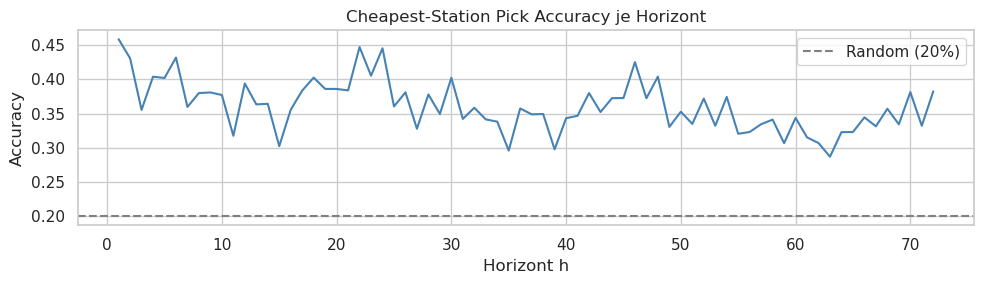

In [15]:
# Cell 5b — Cheapest-Station Pick Accuracy
#
# y_test columns are ordered: for each step 1..72, all 5 stations alphabetically.
# Reshape to (T, H, S) = (time, horizon, station) for argmin over stations.
N_STATIONS = len(SPEDITION_STATIONS)
assert y_true.shape[1] == TARGET_HORIZON * N_STATIONS, "Unexpected y shape"

y_true_3d = y_true.reshape(-1, TARGET_HORIZON, N_STATIONS)  # (T, H, S)
y_pred_3d = y_pred.reshape(-1, TARGET_HORIZON, N_STATIONS)

# argmin(axis=2): cheapest station index per (time, horizon)
true_cheapest = y_true_3d.argmin(axis=2)  # (T, H)
pred_cheapest = y_pred_3d.argmin(axis=2)

accuracy = (true_cheapest == pred_cheapest).mean()
print(f"Cheapest-Station Pick Accuracy: {accuracy:.1%}  (Random Baseline: {1/N_STATIONS:.0%})")

# Accuracy per horizon step
acc_per_step = (true_cheapest == pred_cheapest).mean(axis=0)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(1, TARGET_HORIZON + 1), acc_per_step, color="steelblue")
ax.axhline(1 / N_STATIONS, ls="--", color="gray", label=f"Random ({1/N_STATIONS:.0%})")
ax.set_title("Cheapest-Station Pick Accuracy je Horizont")
ax.set_xlabel("Horizont h"); ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_5162/3100192006.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearmanr(y_true_3d[t, step, :], y_pred_3d[t, step, :]).statistic


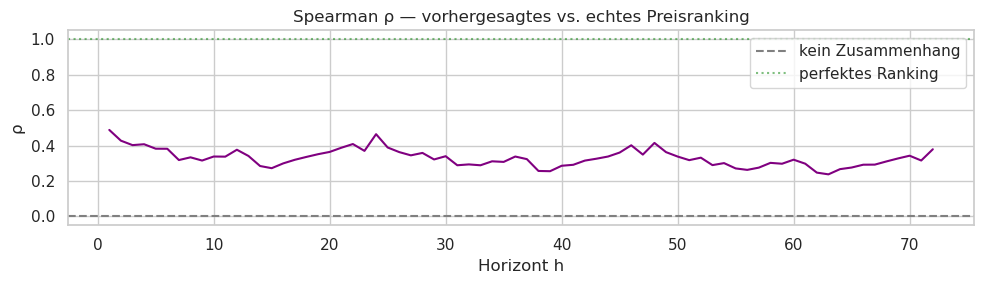

Mittleres Spearman ρ über alle Horizonte: 0.331

Durchschnittlicher Preisspread (günstigste/teuerste): 0.0811 €/L
Mehrkosten täglich bei Zufallsrouting:   129.73 €
Mehrkosten täglich mit MLP-Routing:      103.59 €
Erwartete Einsparung vs. Zufall:         26.14 €/Tag


In [16]:
# Cell 5c — Spearman-Rangkorrelation + Kosten-Impact
spearman_per_step = []
for step in range(TARGET_HORIZON):
    rhos = [
        spearmanr(y_true_3d[t, step, :], y_pred_3d[t, step, :]).statistic
        for t in range(len(y_true_3d))
    ]
    spearman_per_step.append(np.nanmean(rhos))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(1, TARGET_HORIZON + 1), spearman_per_step, color="purple")
ax.axhline(0, ls="--", color="gray", label="kein Zusammenhang")
ax.axhline(1, ls=":", color="green", alpha=0.5, label="perfektes Ranking")
ax.set_title("Spearman ρ — vorhergesagtes vs. echtes Preisranking")
ax.set_xlabel("Horizont h"); ax.set_ylabel("ρ")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mittleres Spearman ρ über alle Horizonte: {np.mean(spearman_per_step):.3f}")

# Kosten-Impact-Simulation
spreads = y_true_3d.max(axis=2) - y_true_3d.min(axis=2)  # (T, H)
avg_spread = spreads.mean()

random_miss_rate = 1 - 1 / N_STATIONS   # zufällige Wahl
model_miss_rate  = 1 - accuracy

daily_cost_random = avg_spread * random_miss_rate * TANK_LITER * N_TRUCKS * FILLS_PER_DAY
daily_cost_model  = avg_spread * model_miss_rate  * TANK_LITER * N_TRUCKS * FILLS_PER_DAY

print(f"\nDurchschnittlicher Preisspread (günstigste/teuerste): {avg_spread:.4f} €/L")
print(f"Mehrkosten täglich bei Zufallsrouting:   {daily_cost_random:.2f} €")
print(f"Mehrkosten täglich mit MLP-Routing:      {daily_cost_model:.2f} €")
print(f"Erwartete Einsparung vs. Zufall:         {daily_cost_random - daily_cost_model:.2f} €/Tag")

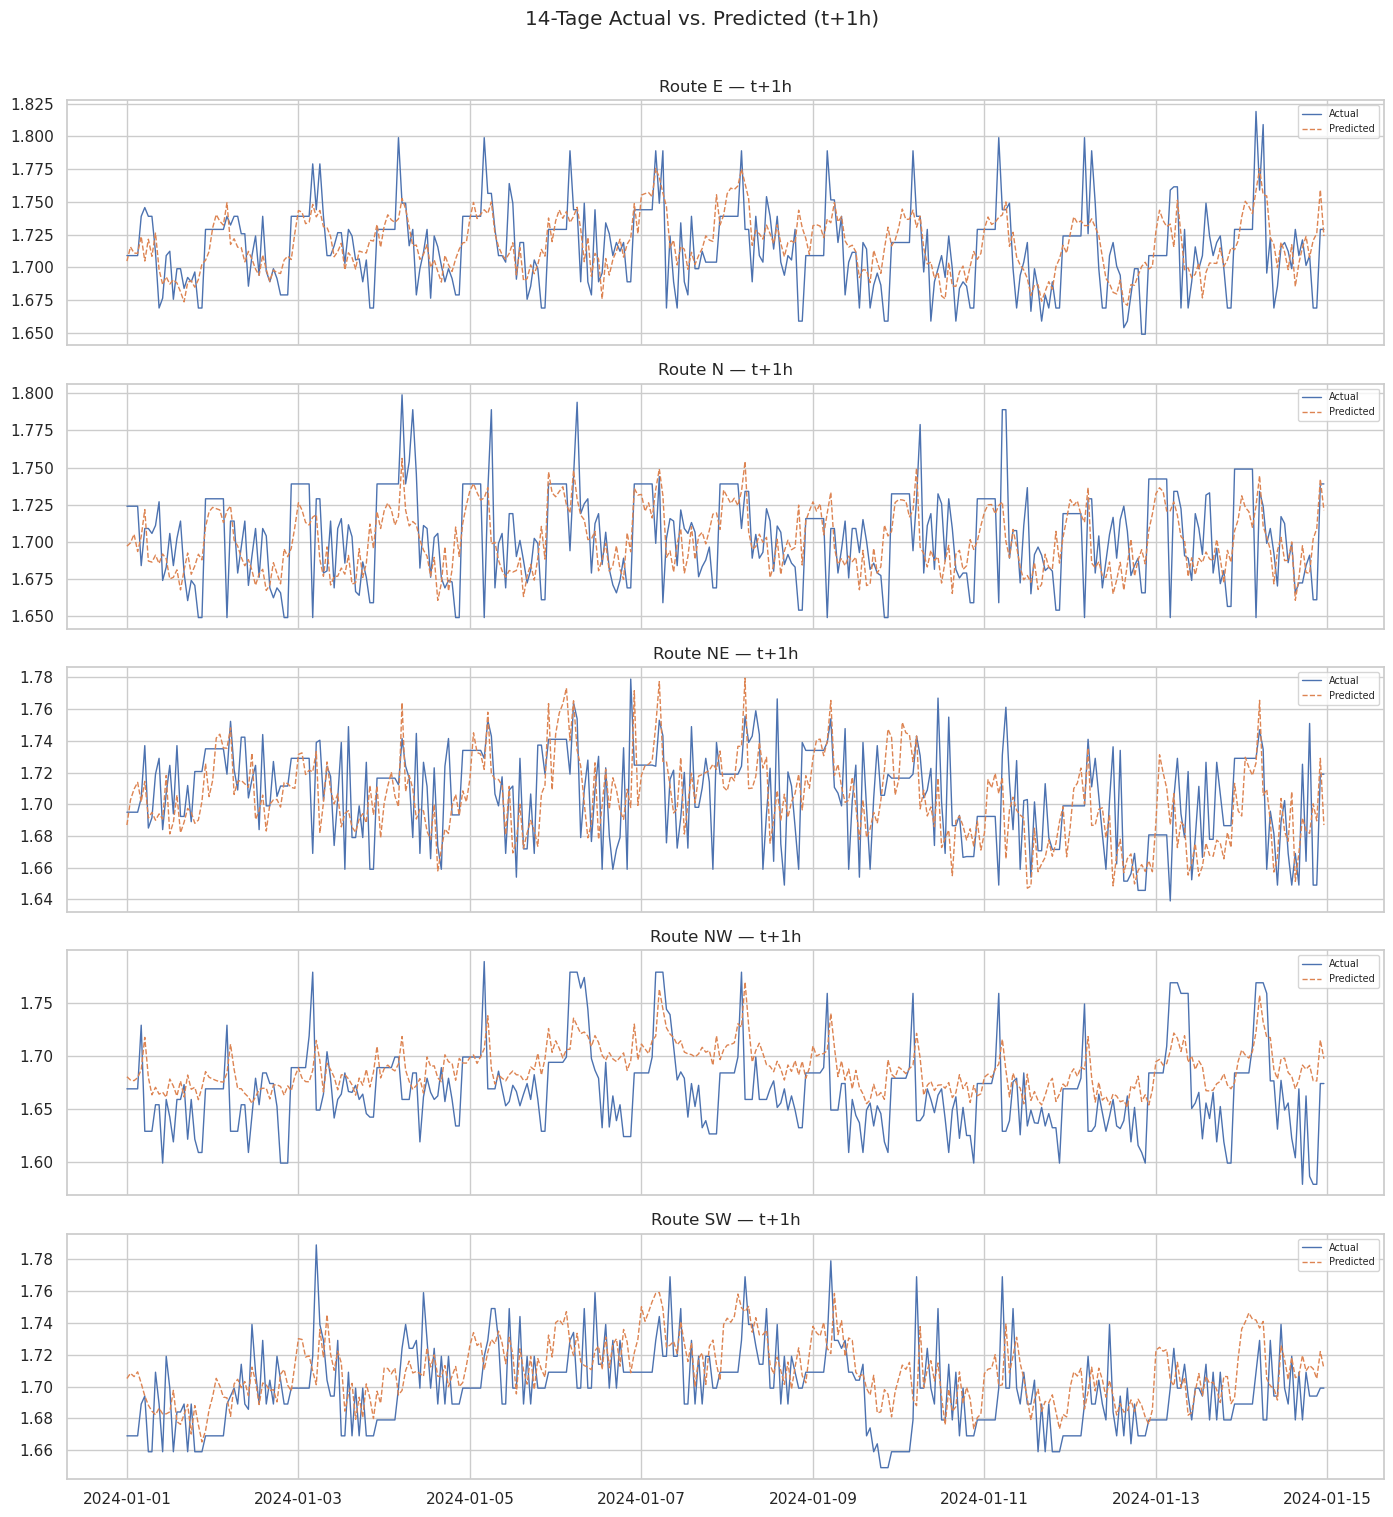

In [17]:
# Cell 5d — 14-Tage Actual vs. Predicted (t+1h je Station)
n_days = 14
sample_end = y_test.index[0] + pd.Timedelta(days=n_days)
sample_idx = y_test.index[(y_test.index >= y_test.index[0]) & (y_test.index < sample_end)]

t1_cols = [c for c in y_test.columns if "t+1h" in c]
station_labels = [c.replace("diesel_Route_", "").replace("_t+1h", "") for c in t1_cols]
t1_idx = [list(y_test.columns).index(c) for c in t1_cols]

fig, axes = plt.subplots(len(t1_cols), 1, figsize=(14, 3 * len(t1_cols)), sharex=True)
for ax, col, label, ci in zip(axes, t1_cols, station_labels, t1_idx):
    mask = y_test.index.isin(sample_idx)
    ax.plot(y_test.index[mask], y_true[mask, ci], label="Actual", lw=1)
    ax.plot(y_test.index[mask], y_pred[mask, ci], label="Predicted", lw=1, ls="--")
    ax.set_title(f"Route {label} — t+1h")
    ax.legend(fontsize=7)
plt.suptitle("14-Tage Actual vs. Predicted (t+1h)", y=1.01)
plt.tight_layout()
plt.show()

---
## § 6 — Deployment

Funktion `recommend_cheapest_station` gibt dem Disponenten eine priorisierte Liste
der günstigsten Stationen für einen wählbaren Horizont zurück.

In [18]:
# Cell 6a — Forecast-Funktion + Beispielausgabe
def recommend_cheapest_station(
    model,
    scaler_X,
    scaler_y,
    X: pd.DataFrame,
    y_columns: list,
    horizon_h: int = 8,
) -> dict:
    """Return ranked station recommendations for a given forecast horizon."""
    latest  = X.iloc[[-1]]
    feat_s  = scaler_X.transform(latest)
    pred_s  = model.predict(feat_s)
    pred    = scaler_y.inverse_transform(pred_s)[0]

    step_cols = [c for c in y_columns if f"t+{horizon_h}h" in c]
    step_idx  = [y_columns.index(c) for c in step_cols]
    prices    = {
        c.replace("diesel_", "").replace(f"_t+{horizon_h}h", ""): pred[i]
        for c, i in zip(step_cols, step_idx)
    }
    ranked   = sorted(prices.items(), key=lambda kv: kv[1])
    cheapest = ranked[0]
    spread   = (ranked[-1][1] - ranked[0][1]) * TANK_LITER

    return {
        "horizon_h":      horizon_h,
        "recommendation": cheapest[0],
        "expected_price": cheapest[1],
        "ranking":        ranked,
        "spread_eur":     spread,
    }


result = recommend_cheapest_station(
    model, scaler_X, scaler_y, X_test, list(y.columns), horizon_h=8
)

ranking_str = " > ".join(f"{r[0]} ({r[1]:.3f})" for r in result["ranking"])
print(f"""
┌─ Dispatch Recommendation ──────────────────────────────────────────┐
│  Horizont     : +{result['horizon_h']}h
│  Günstigste   : {result['recommendation']:<20}  → €{result['expected_price']:.3f}/L
│  Ranking      : {ranking_str}
│  Ersparnis vs. teuerste Station: ~€{result['spread_eur']:.2f} / Befüllung
└────────────────────────────────────────────────────────────────────┘
""")

# Mehrere Horizonte testen
print("Empfehlung nach Horizont:")
print(f"{'Horizont':>10} | {'Günstigste Station':<22} | Preis €/L")
print("-" * 48)
for h in [1, 4, 8, 12, 24, 48, 72]:
    r = recommend_cheapest_station(model, scaler_X, scaler_y, X_test, list(y.columns), horizon_h=h)
    print(f"  t+{h:>3}h    | {r['recommendation']:<22} | {r['expected_price']:.4f}")


┌─ Dispatch Recommendation ──────────────────────────────────────────┐
│  Horizont     : +8h
│  Günstigste   : Route_N               → €1.896/L
│  Ranking      : Route_N (1.896) > Route_NW (1.901) > Route_NE (1.937) > Route_SW (1.997) > Route_E (2.004)
│  Ersparnis vs. teuerste Station: ~€43.08 / Befüllung
└────────────────────────────────────────────────────────────────────┘

Empfehlung nach Horizont:
  Horizont | Günstigste Station     | Preis €/L
------------------------------------------------
  t+  1h    | Route_NW               | 1.9150
  t+  4h    | Route_NW               | 1.8680
  t+  8h    | Route_N                | 1.8962
  t+ 12h    | Route_N                | 1.9044
  t+ 24h    | Route_NW               | 1.8828
  t+ 48h    | Route_NW               | 1.8754
  t+ 72h    | Route_NW               | 1.8802


In [19]:
# Cell 6b — Modell speichern
model_dir = Path("../data/models")
model_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "model":           model,
    "scaler_X":        scaler_X,
    "scaler_y":        scaler_y,
    "feature_columns": list(X.columns),
    "target_columns":  list(y.columns),
    "station_uuids":   SPEDITION_STATIONS,
    "fuel_type":       "diesel",
    "forecast_horizon": TARGET_HORIZON,
}
save_path = model_dir / "spedition_mlp.joblib"
joblib.dump(artifact, save_path)
print(f"Modell gespeichert → {save_path}")

# Verify reload
loaded = joblib.load(save_path)
print(f"Reload OK — Modell-Typ: {type(loaded['model']).__name__}")
print(f"Feature-Spalten: {len(loaded['feature_columns'])} | Ziel-Spalten: {len(loaded['target_columns'])}")

Modell gespeichert → ../data/models/spedition_mlp.joblib
Reload OK — Modell-Typ: MLPRegressor
Feature-Spalten: 99 | Ziel-Spalten: 360
